In [5]:
from datasets import load_dataset
import pandas as pd
 
# Load the unsplit dataset
ds = load_dataset("dair-ai/emotion", "unsplit")
 
# Access the full data (stored in the 'train' key)
full_data = ds["train"]
 
# Convert to Pandas DataFrame
df = full_data.to_pandas()
 
# Optional: Map integer labels to emotion names for clarity
label_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}
df['label_name'] = df['label'].map(label_map)
 
# Save to CSV
df.to_csv("emotion_dataset_full.csv", index=False)
 
print("Dataset saved to 'emotion_dataset_full.csv'")  

/home/chris/Documents/Broadway Python/Lesson 1/venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 100%|██████████| 416809/416809 [00:00<00:00, 1978926.96 examples/s]


Dataset saved to 'emotion_dataset_full.csv'


In [26]:
import pandas as pd

df = pd.read_csv(r'/home/chris/Documents/Broadway Python/Lesson 1/Machine Learning/KNN/emotion_dataset_full.csv')
df.head()

,text,label,label_name
0,i feel awful about it too because it s my job ...,0,sadness
1,im alone i feel awful,0,sadness
2,ive probably mentioned this before but i reall...,1,joy
3,i was feeling a little low few days back,0,sadness
4,i beleive that i am much more sensitive to oth...,2,love


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   text        416809 non-null  str  
 1   label       416809 non-null  int64
 2   label_name  416809 non-null  str  
dtypes: int64(1), str(2)
memory usage: 50.0 MB


In [28]:
df.describe()

,label
count,416809.000000
mean,1.554271
std,1.490453
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,5.000000


In [29]:
df.drop(columns='label', inplace=True)
df

,text,label_name
0,i feel awful about it too because it s my job ...,sadness
1,im alone i feel awful,sadness
2,ive probably mentioned this before but i reall...,joy
3,i was feeling a little low few days back,sadness
4,i beleive that i am much more sensitive to oth...,love
...,...,...
416804,that was what i felt when i was finally accept...,joy
416805,i take every day as it comes i m just focussin...,fear
416806,i just suddenly feel that everything was fake,sadness
416807,im feeling more eager than ever to claw back w...,joy


In [30]:
df.isnull().sum()

text          0
label_name    0
dtype: int64

<Axes: title={'center': 'Distribution of Emotions'}, xlabel='label_name'>

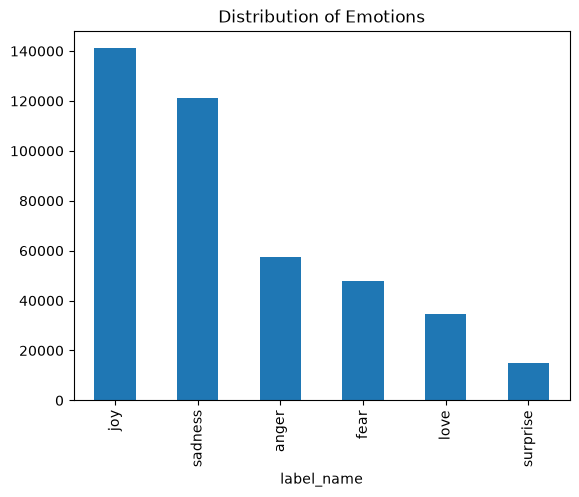

In [31]:
df['label_name'].value_counts().plot(kind='bar', title='Distribution of Emotions')

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_name_encoded'] = le.fit_transform(df['label_name'])

label_encoding_map = dict(zip(le.classes_, le.transform(le.classes_)))
print(label_encoding_map)

df.head()

{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}


,text,label_name,label_name_encoded
0,i feel awful about it too because it s my job ...,sadness,4
1,im alone i feel awful,sadness,4
2,ive probably mentioned this before but i reall...,joy,2
3,i was feeling a little low few days back,sadness,4
4,i beleive that i am much more sensitive to oth...,love,3


In [33]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['label_name']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=1,
                                                    stratify=y)

print('the shape of the train data set is : ', X_train.shape)
print('the shape of the test data set is : ', X_test.shape)

the shape of the train data set is :  (291766,)
the shape of the test data set is :  (125043,)


In [ ]:
df.head()

,text,label_name
0,i feel awful about it too because it s my job ...,sadness
1,im alone i feel awful,sadness
2,ive probably mentioned this before but i reall...,joy
3,i was feeling a little low few days back,sadness
4,i beleive that i am much more sensitive to oth...,love


In [35]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words=['english', 'the', 'a', 'an', 'and', 'or', 'but', 'if', 'while', 'of', 'to', 'in', 'on', 'for', 'with', 'as', 'by', 'at'])
X_train_vec = cv.fit_transform(X_train)
X_test_vec = cv.transform(X_test)

print('Vocabulary size :', len(cv.vocabulary_))
print('X_train_vec shape:', X_train_vec.shape)
print('X_test_vec shape :', X_test_vec.shape)

Vocabulary size : 63538
X_train_vec shape: (291766, 63538)
X_test_vec shape : (125043, 63538)


In [36]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

In [37]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8573


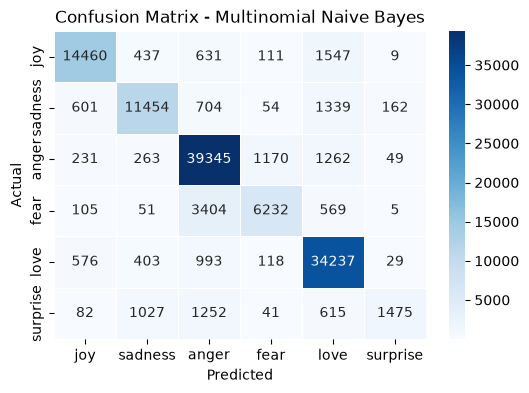

In [42]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'],
            yticklabels=['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'],
            linewidths=0.5)
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [43]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['joy', 'sadness', 'anger', 'fear', 'love', 'surprise']))

              precision    recall  f1-score   support

         joy       0.90      0.84      0.87     17195
     sadness       0.84      0.80      0.82     14314
       anger       0.85      0.93      0.89     42320
        fear       0.81      0.60      0.69     10366
        love       0.87      0.94      0.90     36356
    surprise       0.85      0.33      0.47      4492

    accuracy                           0.86    125043
   macro avg       0.85      0.74      0.77    125043
weighted avg       0.86      0.86      0.85    125043

